In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [78]:
from google.colab import files
uploaded = files.upload()

Saving distribution_equipment_risk_dataset.csv to distribution_equipment_risk_dataset (3).csv


In [79]:
df = pd.read_csv("distribution_equipment_risk_dataset.csv")
df.head()

,equipment_id,timestamp,equipment_type,location_lat,location_long,ambient_temperature_C,humidity_percent,wind_speed_mps,precipitation_mm,load_current_A,voltage_kV,smart_meter_gasp_signal,vibration_level_g,insulation_resistance_MOhm,oil_temperature_C,historical_failures_count,time_since_last_failure_days,risk_score,risk_level
0,EQ_0000,2024-01-01 00:00:00,Transformer,18.861663,95.570715,44.279758,67.892679,2.340280,3.119890,70.329264,29.386756,0,0.921617,7.372653,41.132147,5,140,0.517,Medium
1,EQ_0001,2024-01-01 01:00:00,CircuitBreaker,36.127386,92.140837,23.493564,34.545997,2.751068,6.084845,233.664751,17.662516,0,0.472282,6.506676,NaN,1,377,0.281,Low
2,EQ_0002,2024-01-01 02:00:00,Transformer,12.045322,76.472195,29.654474,56.485599,11.777639,3.993476,229.982053,21.995193,0,0.117353,6.467904,49.378827,4,216,0.328,Low
3,EQ_0003,2024-01-01 03:00:00,Transformer,9.886496,95.517681,53.625281,84.671788,4.569207,1.953442,289.481559,17.884117,0,0.226955,5.456592,41.891369,0,111,0.414,Medium
4,EQ_0004,2024-01-01 04:00:00,CircuitBreaker,34.370292,75.504619,41.500891,44.936886,7.801020,10.934206,114.699059,32.178785,0,1.173943,9.455490,NaN,4,101,0.474,Medium


In [80]:
df.shape

(1000, 19)

In [81]:
df.columns

Index(['equipment_id', 'timestamp', 'equipment_type', 'location_lat',
       'location_long', 'ambient_temperature_C', 'humidity_percent',
       'wind_speed_mps', 'precipitation_mm', 'load_current_A', 'voltage_kV',
       'smart_meter_gasp_signal', 'vibration_level_g',
       'insulation_resistance_MOhm', 'oil_temperature_C',
       'historical_failures_count', 'time_since_last_failure_days',
       'risk_score', 'risk_level'],
      dtype='object')

In [82]:
df.describe()

,location_lat,location_long,ambient_temperature_C,humidity_percent,wind_speed_mps,precipitation_mm,load_current_A,voltage_kV,smart_meter_gasp_signal,vibration_level_g,insulation_resistance_MOhm,oil_temperature_C,historical_failures_count,time_since_last_failure_days,risk_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,179.000000,1000.000000,1000.000000,1000.000000
mean,21.993641,82.520671,35.020489,59.860755,7.482444,9.656454,227.124961,19.261963,0.505000,0.750163,5.471141,67.221874,2.578000,252.830000,0.534178
std,8.522162,8.435713,11.438407,23.318674,4.323760,5.714254,101.160308,7.720625,0.500225,0.403212,2.546679,17.210635,1.716643,144.371508,0.139578
min,8.001532,68.006584,15.058953,20.000931,0.009801,0.060417,50.085027,6.000829,0.000000,0.050195,1.008491,40.043423,0.000000,0.000000,0.163000
25%,14.477508,75.250152,25.050661,39.848924,3.719542,4.912651,138.564239,12.696785,0.000000,0.399604,3.298868,50.562454,1.000000,127.000000,0.429000
50%,21.677500,82.456762,34.945359,59.862875,7.489243,9.640360,228.551377,19.338242,1.000000,0.737112,5.487034,67.971388,3.000000,249.500000,0.531500
75%,29.162202,89.944626,44.928606,79.820241,11.182343,14.609111,316.332146,25.706753,1.000000,1.084619,7.634104,81.676682,4.000000,381.000000,0.633250
max,36.991813,96.982998,54.968292,99.960415,14.976319,19.903188,399.845196,32.985438,1.000000,1.499058,9.990142,94.758231,5.000000,500.000000,0.921000


In [83]:
df.tail()

,equipment_id,timestamp,equipment_type,location_lat,location_long,ambient_temperature_C,humidity_percent,wind_speed_mps,precipitation_mm,load_current_A,voltage_kV,smart_meter_gasp_signal,vibration_level_g,insulation_resistance_MOhm,oil_temperature_C,historical_failures_count,time_since_last_failure_days,risk_score,risk_level
995,EQ_0995,2024-02-11 11:00:00,Switch,27.773158,96.811545,24.293422,69.915646,6.904821,0.789039,55.064725,9.219172,0,0.991183,6.104468,NaN,1,374,0.363,Low
996,EQ_0996,2024-02-11 12:00:00,Cable,24.049457,68.923846,33.772120,93.969825,5.963878,12.498449,322.936536,27.165983,1,0.802956,8.721568,NaN,5,162,0.617,Medium
997,EQ_0997,2024-02-11 13:00:00,CircuitBreaker,19.349965,93.772103,24.609087,42.417313,0.796809,15.911637,195.969333,12.186149,1,0.386096,9.112599,NaN,1,340,0.423,Medium
998,EQ_0998,2024-02-11 14:00:00,Relay,32.183581,84.052396,39.644432,57.946046,5.874998,18.309538,93.964446,17.298063,0,0.549615,5.483356,NaN,3,157,0.440,Medium
999,EQ_0999,2024-02-11 15:00:00,Switch,21.271324,83.047796,20.596759,61.051320,3.636282,3.686627,72.691977,26.591619,0,0.669791,6.639793,NaN,1,373,0.289,Low


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   equipment_id                  1000 non-null   object 
 1   timestamp                     1000 non-null   object 
 2   equipment_type                1000 non-null   object 
 3   location_lat                  1000 non-null   float64
 4   location_long                 1000 non-null   float64
 5   ambient_temperature_C         1000 non-null   float64
 6   humidity_percent              1000 non-null   float64
 7   wind_speed_mps                1000 non-null   float64
 8   precipitation_mm              1000 non-null   float64
 9   load_current_A                1000 non-null   float64
 10  voltage_kV                    1000 non-null   float64
 11  smart_meter_gasp_signal       1000 non-null   int64  
 12  vibration_level_g             1000 non-null   float64
 13  insu

In [85]:
df.isnull().sum()

,0
equipment_id,0
timestamp,0
equipment_type,0
location_lat,0
location_long,0
ambient_temperature_C,0
humidity_percent,0
wind_speed_mps,0
precipitation_mm,0
load_current_A,0


In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
df.nunique()

,0
equipment_id,1000
timestamp,1000
equipment_type,5
location_lat,1000
location_long,1000
ambient_temperature_C,1000
humidity_percent,1000
wind_speed_mps,1000
precipitation_mm,1000
load_current_A,1000


In [88]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
(df[numeric_cols] < 0).sum()

,0
location_lat,0
location_long,0
ambient_temperature_C,0
humidity_percent,0
wind_speed_mps,0
precipitation_mm,0
load_current_A,0
voltage_kV,0
smart_meter_gasp_signal,0
vibration_level_g,0


In [89]:
df['risk_level'].value_counts()


,count
risk_level,
Medium,691
Low,182
High,127


In [90]:
df['equipment_type'].value_counts()

,count
equipment_type,
CircuitBreaker,209
Relay,208
Switch,206
Cable,198
Transformer,179


In [91]:
df_clean = df.copy()

In [92]:
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

In [93]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   equipment_id                  1000 non-null   object        
 1   timestamp                     1000 non-null   datetime64[ns]
 2   equipment_type                1000 non-null   object        
 3   location_lat                  1000 non-null   float64       
 4   location_long                 1000 non-null   float64       
 5   ambient_temperature_C         1000 non-null   float64       
 6   humidity_percent              1000 non-null   float64       
 7   wind_speed_mps                1000 non-null   float64       
 8   precipitation_mm              1000 non-null   float64       
 9   load_current_A                1000 non-null   float64       
 10  voltage_kV                    1000 non-null   float64       
 11  smart_meter_gasp_signal       1

In [94]:
df_clean = df_clean.drop(columns=['oil_temperature_C', 'timestamp', 'risk_level'])

In [96]:
df_clean.head()

,equipment_id,equipment_type,location_lat,location_long,ambient_temperature_C,humidity_percent,wind_speed_mps,precipitation_mm,load_current_A,voltage_kV,smart_meter_gasp_signal,vibration_level_g,insulation_resistance_MOhm,historical_failures_count,time_since_last_failure_days,risk_score
0,EQ_0000,Transformer,18.861663,95.570715,44.279758,67.892679,2.340280,3.119890,70.329264,29.386756,0,0.921617,7.372653,5,140,0.517
1,EQ_0001,CircuitBreaker,36.127386,92.140837,23.493564,34.545997,2.751068,6.084845,233.664751,17.662516,0,0.472282,6.506676,1,377,0.281
2,EQ_0002,Transformer,12.045322,76.472195,29.654474,56.485599,11.777639,3.993476,229.982053,21.995193,0,0.117353,6.467904,4,216,0.328
3,EQ_0003,Transformer,9.886496,95.517681,53.625281,84.671788,4.569207,1.953442,289.481559,17.884117,0,0.226955,5.456592,0,111,0.414
4,EQ_0004,CircuitBreaker,34.370292,75.504619,41.500891,44.936886,7.801020,10.934206,114.699059,32.178785,0,1.173943,9.455490,4,101,0.474


In [97]:
df_clean.shape

(1000, 16)

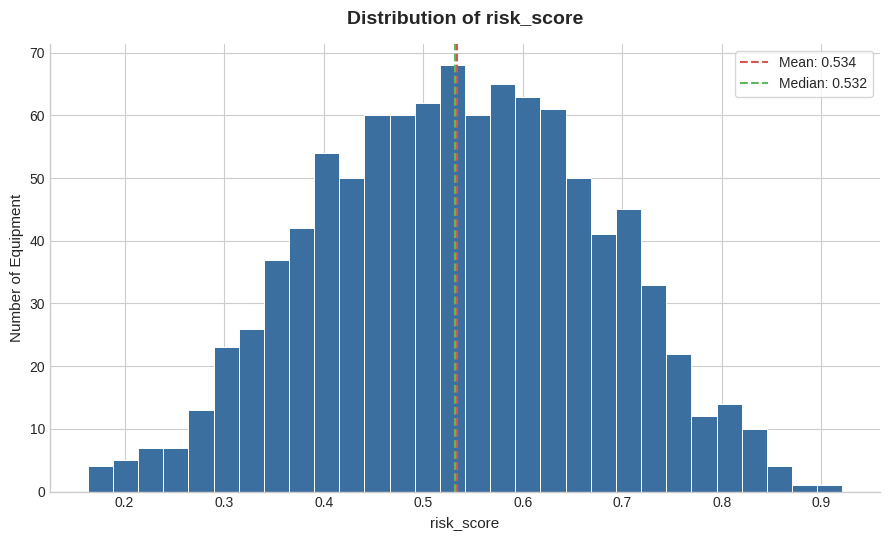

In [98]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(9,5.5), dpi=100)

ax.hist(df_clean['risk_score'], bins=30, color='#3B6FA0', edgecolor='white', linewidth=0.7)

mean_val = df_clean['risk_score'].mean()
median_val = df_clean['risk_score'].median()

ax.axvline(mean_val, color='#D9534F', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.3f}')
ax.axvline(median_val, color='#5CB85C', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.3f}')

ax.set_title('Distribution of risk_score', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('risk_score', fontsize=11)
ax.set_ylabel('Number of Equipment', fontsize=11)
ax.legend(fontsize=10, frameon=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

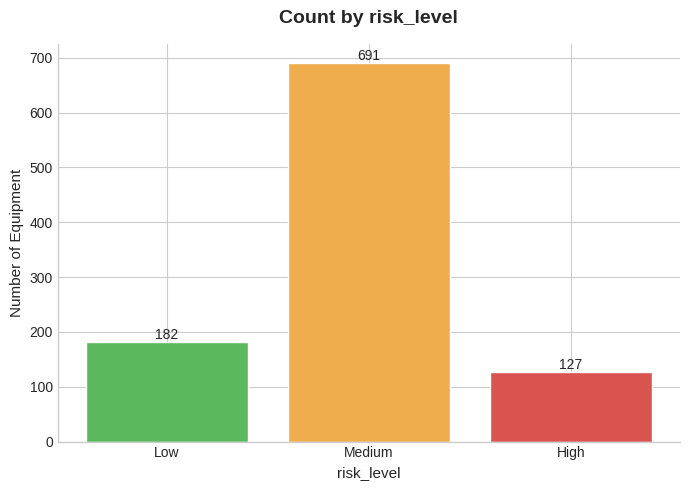

In [99]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(7,5), dpi=100)

order = ['Low', 'Medium', 'High']
counts = df['risk_level'].value_counts().reindex(order)

bars = ax.bar(counts.index, counts.values, color=['#5CB85C', '#F0AD4E', '#D9534F'], edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 5, int(height), ha='center', fontsize=10)

ax.set_title('Count by risk_level', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('risk_level', fontsize=11)
ax.set_ylabel('Number of Equipment', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

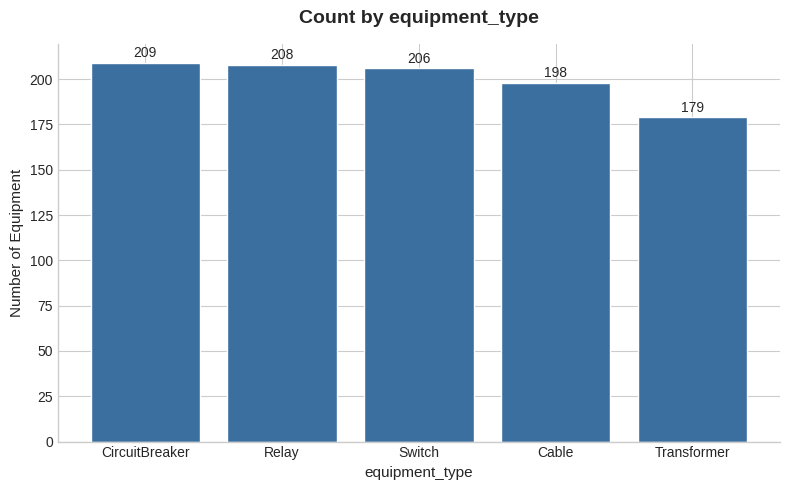

In [100]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8,5), dpi=100)

counts = df_clean['equipment_type'].value_counts().sort_values(ascending=False)

bars = ax.bar(counts.index, counts.values, color='#3B6FA0', edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 3, int(height), ha='center', fontsize=10)

ax.set_title('Count by equipment_type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('equipment_type', fontsize=11)
ax.set_ylabel('Number of Equipment', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

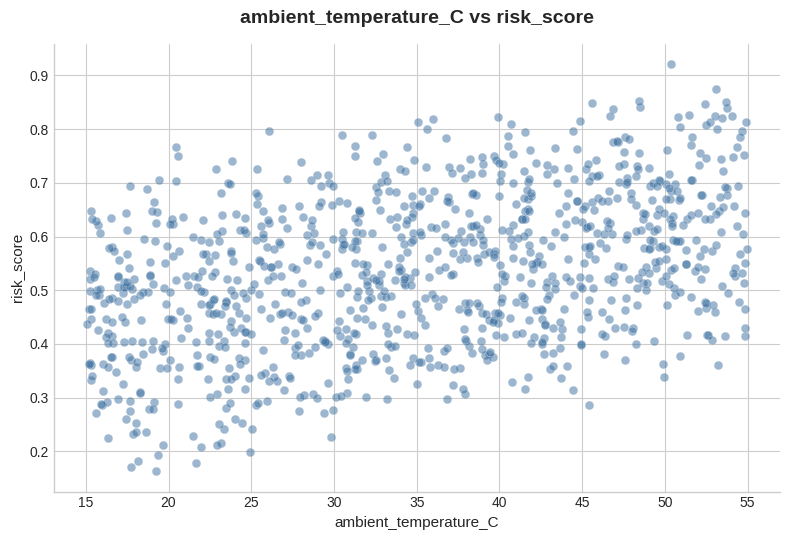

In [101]:
  plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8,5.5), dpi=100)

ax.scatter(df_clean['ambient_temperature_C'], df_clean['risk_score'],
           alpha=0.5, color='#3B6FA0', edgecolor='white', linewidth=0.3, s=40)

ax.set_title('ambient_temperature_C vs risk_score', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('ambient_temperature_C', fontsize=11)
ax.set_ylabel('risk_score', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [102]:
X = df_clean.drop(columns=['equipment_id', 'risk_score'])
y = df_clean['risk_score']

In [103]:
X = pd.get_dummies(X, columns=['equipment_type'])

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(800, 18) (200, 18) (800,) (200,)


In [106]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.022006050000000017
MSE: 0.0008090441695000008
RMSE: 0.028443701754518536
R2 Score: 0.9584958267498004


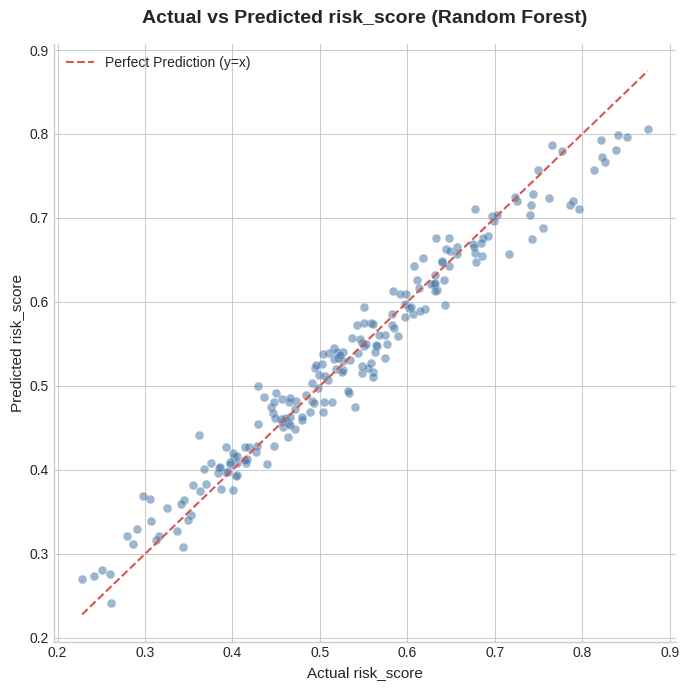

In [107]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(7,7), dpi=100)

ax.scatter(y_test, y_pred, alpha=0.5, color='#3B6FA0', edgecolor='white', linewidth=0.3, s=40)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color='#D9534F', linestyle='--', linewidth=1.5, label='Perfect Prediction (y=x)')

ax.set_title('Actual vs Predicted risk_score (Random Forest)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Actual risk_score', fontsize=11)
ax.set_ylabel('Predicted risk_score', fontsize=11)
ax.legend(fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()